# Measure analysis

##### Imports and params

In [1]:
from __future__ import annotations

import pandas as pd

from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({
"figure.figsize": (18, 10),
"axes.grid": True,
"grid.linestyle": ":",
"grid.alpha": 0.5,
"axes.titlesize": 14,
"axes.labelsize": 12,
"legend.fontsize": 10,
})

In [3]:
MORPHO_RESULTS = Path("/home/loai/Documents/code/RSMLExtraction/RSA_reconstruction/Method/ChronoRoot/GLOBAL_MORPHOLOGY.csv").expanduser()
DYNAMIC_RESULTS = Path("/home/loai/Documents/code/RSMLExtraction/RSA_reconstruction/Method/ChronoRoot/GLOBAL_DYNAMICS.csv").expanduser()
GT_MORPHO_RESULTS = Path("/home/loai/Documents/code/RSMLExtraction/RSA_reconstruction/Method/ChronoRoot/Ground_truth_root.csv").expanduser()
PATH_2_LOGS = Path("/home/loai/Documents/code/RSMLExtraction/RSA_reconstruction/Method/ChronoRoot/all_events_combined.csv").expanduser()

## Loading database

In [4]:
df_plant_morpho = pd.read_csv(MORPHO_RESULTS)

df_plant_morpho = df_plant_morpho.drop(columns=["FileName"])

# order by box_name, img_num, plant_num, Time elapsed (hours)
df_plant_morpho = df_plant_morpho.sort_values(by=["box_name", "img_num", "plant_num", "Time elapsed (hours)"])

df_plant_morpho.head()

,box_name,loss_name,epoch,img_num,plant_num,TimeStep,MainRootLength,LateralRootsLength,NumberOfLateralRoots,TotalLength,TotalOrganCount,ConvexHullArea,RootDensity,Time elapsed (hours),Acquisition Time
3459,rpi14_2020-01-08_17-25,CLDICE,5,1,2,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
11504,rpi14_2020-01-08_17-25,CLDICE,125,1,2,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
22504,rpi14_2020-01-08_17-25,CLDICE,130,1,2,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
34072,rpi14_2020-01-08_17-25,CLDICE,70,1,2,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
45431,rpi14_2020-01-08_17-25,CLDICE,155,1,2,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0


In [5]:
time_step_hours = df_plant_morpho['Time elapsed (hours)'].diff().loc[df_plant_morpho['Time elapsed (hours)'].diff() > 0].median()
print(f"Intervalle détecté entre les images : {time_step_hours} heures (soit {time_step_hours*60} min)")

Intervalle détecté entre les images : 0.25 heures (soit 15.0 min)


In [6]:
df_plant_dynamics = pd.read_csv(DYNAMIC_RESULTS)

df_plant_dynamics = df_plant_dynamics.drop(columns=["newDay"])

df_plant_dynamics['Time elapsed (hours)'] = df_plant_dynamics['Time'] * 4 * time_step_hours

all_messurements = [col for col in df_plant_dynamics.columns if col not in ['box_name', 'img_num', 'plant_num', 'Time']]

for col in all_messurements:
    if col.endswith('Grad'):
        df_plant_dynamics[col] = df_plant_dynamics[col] * 4 * time_step_hours
    if col.endswith('Accel'):
        df_plant_dynamics[col] = df_plant_dynamics[col] * (4 * time_step_hours) **2

# order by box_name, img_num, plant_num, time
df_plant_dynamics = df_plant_dynamics.sort_values(by=["box_name", "img_num", "plant_num", "Time"])

cols = ['box_name', 'img_num', 'plant_num', 'Time elapsed (hours)']
cols += [c for c in df_plant_dynamics.columns if c not in cols]
df_plant_dynamics = df_plant_dynamics[cols]

df_plant_dynamics.head()

,box_name,img_num,plant_num,Time elapsed (hours),loss_name,epoch,Time,mainRootLength,lateralRootsLength,totalRootsLength,...,totalRootsGrad,mainRootAccel,lateralRootsAccel,totalRootsAccel,NumberOfLateralRoots,ConvexHullArea,RootDensity,mainOverTotal,lateralRootDensity,lateralRootContDensity
864,rpi14_2020-01-08_17-25,1,2,0.0,CLDICE,5,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
2874,rpi14_2020-01-08_17-25,1,2,0.0,CLDICE,125,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
5621,rpi14_2020-01-08_17-25,1,2,0.0,CLDICE,130,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
8510,rpi14_2020-01-08_17-25,1,2,0.0,CLDICE,70,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0
11346,rpi14_2020-01-08_17-25,1,2,0.0,CLDICE,155,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0


In [7]:
df_ground_truth = pd.read_csv(GT_MORPHO_RESULTS)
df_ground_truth = df_ground_truth.drop(columns=["FileName"])

df_ground_truth = df_ground_truth.sort_values(by=["box_name", "img_num", "plant_num", "Time elapsed (hours)"])

# rename columns in df_ground_truth to match df_plant_morpho
df_ground_truth = df_ground_truth.rename(columns={
    "PrimaryRootLength": "MainRootLength",
    "LateralRootLength": "LateralRootsLength",
    "TotalRootLength": "TotalLength",
    "NumberOfLateralRoots": "NumberOfLateralRoots",
    "mainRootGrad": "mainRootGrad",
    "mainRootAccel": "mainRootAccel",
    "lateralRootsGrad": "lateralRootsGrad",
    "lateralRootsAccel": "lateralRootsAccel",
    "totalRootsGrad": "totalRootsGrad",
    "totalRootsAccel": "totalRootsAccel",
    "NumberOfOrgans": "TotalOrganCount",
    "Convex_Area_Hull": "ConvexHullArea",
    "RootDensity": "RootDensity",
})

# remove rows with Missing Values
df_ground_truth = df_ground_truth.dropna()

df_ground_truth.head()

,box_name,img_num,plant_num,TimeStep,TotalLength,LateralRootsLength,NumberOfLateralRoots,mainRootGrad,mainRootAccel,lateralRootsGrad,lateralRootsAccel,totalRootsGrad,totalRootsAccel,TotalOrganCount,ConvexHullArea,RootDensity,Time elapsed (hours),Acquisition Time,MainRootLength
9598,rpi14_2020-01-08_17-25,1,1,431,1.889706,0.0,0.0,0.000000,-1.545097,0.0,0.0,0.000000,-1.545097,1,0.0960,19.684434,107.75,11.45,1.889706
9599,rpi14_2020-01-08_17-25,1,1,432,1.833137,0.0,0.0,-0.226274,-0.905097,0.0,0.0,-0.226274,-0.905097,1,0.0600,30.552285,108.00,12.00,1.833137
9600,rpi14_2020-01-08_17-25,1,1,433,1.833137,0.0,0.0,0.000000,0.905097,0.0,0.0,0.000000,0.905097,1,0.0592,30.965153,108.25,12.15,1.833137
9601,rpi14_2020-01-08_17-25,1,1,434,1.833137,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1,0.0600,30.552285,108.50,12.30,1.833137
9602,rpi14_2020-01-08_17-25,1,1,435,1.929706,0.0,0.0,0.386274,1.545097,0.0,0.0,0.386274,1.545097,1,0.0976,19.771574,108.75,12.45,1.929706


In [8]:
cols_to_keep = ['step', 'value', 'folder', 'metric']
df_logs_tb = pd.read_csv(PATH_2_LOGS, usecols=lambda c: c in cols_to_keep)

df_logs_tb = df_logs_tb.rename(columns={"step": "epoch", "value": "model_metric_value"})

meta_data = df_logs_tb['folder'].str.split('/', expand=True)
df_logs_tb['model_name'] = meta_data[11]
df_logs_tb['loss_name'] = meta_data[10]

df_logs_tb = df_logs_tb[df_logs_tb['metric'] != 'batch_loss']
# drop learning rate
df_logs_tb = df_logs_tb[df_logs_tb['metric'] != 'learning_rate']

df_logs_tb = df_logs_tb.drop(columns=['folder'])
df_logs_tb.head()


,metric,model_metric_value,epoch,model_name,loss_name
10000,epoch_loss,0.335330,0,ResUNet,CLDICE
10001,epoch_loss,0.309060,1,ResUNet,CLDICE
10002,epoch_loss,0.294935,2,ResUNet,CLDICE
10003,epoch_loss,0.290948,3,ResUNet,CLDICE
10004,epoch_loss,0.286203,4,ResUNet,CLDICE


In [9]:
# all model_name, loss_name and metric + model_metric_value at last epoch
df_logs_tb_last_epoch = df_logs_tb.groupby(['model_name', 'loss_name', 'metric']).last().reset_index()
max_for_each_loss_name = df_logs_tb_last_epoch.groupby(['loss_name', 'metric'])['model_metric_value'].min().reset_index()
max_for_each_loss_name

,loss_name,metric,model_metric_value
0,BCE,epoch_loss,0.011679
1,BCE,val_auc_gpu,0.958168
2,BCE,val_betti_0_abs_err,21.018183
3,BCE,val_betti_0_err,0.666567
4,BCE,val_betti_1_abs_err,27.818182
5,BCE,val_betti_1_err,0.365518
6,BCE,val_dice,0.712973
7,BCE,val_dice_gpu,0.994794
8,BCE,val_f1,0.712973
9,BCE,val_hausdorff_95,4.905656


## Prepare diff datasets

### Morpho

In [10]:
merge_keys = ["box_name", "img_num", "plant_num", "Time elapsed (hours)", "Acquisition Time"]
df_merged_morpho = pd.merge(
    df_plant_morpho, 
    df_ground_truth, 
    on=merge_keys, 
    how="inner", 
    suffixes=('_pred', '_gt')
)

measurement_cols = [col for col in df_merged_morpho.columns if col.endswith('_pred') or col.endswith('_gt')]
df_merged_morpho = df_merged_morpho[merge_keys + measurement_cols + ["loss_name", "epoch"]]

df_merged_morpho.head()

,box_name,img_num,plant_num,Time elapsed (hours),Acquisition Time,TimeStep_pred,MainRootLength_pred,LateralRootsLength_pred,NumberOfLateralRoots_pred,TotalLength_pred,...,TimeStep_gt,TotalLength_gt,LateralRootsLength_gt,NumberOfLateralRoots_gt,TotalOrganCount_gt,ConvexHullArea_gt,RootDensity_gt,MainRootLength_gt,loss_name,epoch
0,rpi14_2020-01-08_17-25,1,2,122.75,2.45,491,1.778148,0.0,0.0,1.778148,...,491,0.369706,0.0,0.0,1,0.0088,42.012003,0.369706,CLDICE,5
1,rpi14_2020-01-08_17-25,1,2,122.75,2.45,491,4.551405,0.0,0.0,4.551405,...,491,0.369706,0.0,0.0,1,0.0088,42.012003,0.369706,CLDICE,125
2,rpi14_2020-01-08_17-25,1,2,122.75,2.45,491,4.519847,0.0,0.0,4.519847,...,491,0.369706,0.0,0.0,1,0.0088,42.012003,0.369706,CLDICE,130
3,rpi14_2020-01-08_17-25,1,2,122.75,2.45,491,5.075271,0.0,0.0,5.075271,...,491,0.369706,0.0,0.0,1,0.0088,42.012003,0.369706,CLDICE,70
4,rpi14_2020-01-08_17-25,1,2,122.75,2.45,491,4.496993,0.0,0.0,4.496993,...,491,0.369706,0.0,0.0,1,0.0088,42.012003,0.369706,CLDICE,155


In [11]:
pred_cols = [c for c in df_merged_morpho.columns if c.endswith('_pred')]
base_metrics = [c.replace('_pred', '') for c in pred_cols]

valid_metrics = [m for m in base_metrics if f"{m}_gt" in df_merged_morpho.columns]

if 'Time elapsed (hours)_pred' in df_merged_morpho.columns:
    df_merged_morpho = df_merged_morpho.rename(columns={'Time elapsed (hours)_pred': 'Time elapsed (hours)'})

potential_meta_cols = ["box_name", "img_num", "plant_num", "epoch", "loss_name", "Time elapsed (hours)", "Acquisition Time"]
meta_cols = [c for c in potential_meta_cols if c in df_merged_morpho.columns]

df_diff_morpho = df_merged_morpho[meta_cols].copy()

for metric in valid_metrics:
    df_diff_morpho[f"{metric}_signed_err"] = df_merged_morpho[f"{metric}_pred"] - df_merged_morpho[f"{metric}_gt"]
    
    df_diff_morpho[f"{metric}_abs_err"] = df_diff_morpho[f"{metric}_signed_err"].abs()
    
    floatgt = df_merged_morpho[f"{metric}_gt"].astype(float).replace(0, pd.NA)
    df_diff_morpho[f'{metric}_rel_err'] = df_diff_morpho[f"{metric}_abs_err"] / (floatgt + 1e-9)
    
# drop TimeStep_pred and TimeStep_gt if they exist
df_diff_morpho = df_diff_morpho.drop(columns=[col for col in ['TimeStep_signed_err', 'TimeStep_abs_err', 'TimeStep_rel_err'] if col in df_diff_morpho.columns])

df_diff_morpho.dropna(inplace=True)

df_diff_morpho.head()

,box_name,img_num,plant_num,epoch,loss_name,Time elapsed (hours),Acquisition Time,MainRootLength_signed_err,MainRootLength_abs_err,MainRootLength_rel_err,...,TotalLength_rel_err,TotalOrganCount_signed_err,TotalOrganCount_abs_err,TotalOrganCount_rel_err,ConvexHullArea_signed_err,ConvexHullArea_abs_err,ConvexHullArea_rel_err,RootDensity_signed_err,RootDensity_abs_err,RootDensity_rel_err
67872,rpi14_2020-01-08_17-25,1,2,125,CLDICE,296.25,8.15,42.004672,42.004672,5.762736,...,7.637099,5,5,2.5,106.325333,106.325333,23.510820,-1.072981,1.072981,0.647103
67873,rpi14_2020-01-08_17-25,1,2,130,CLDICE,296.25,8.15,42.028735,42.028735,5.766037,...,7.690288,6,6,3.0,106.705422,106.705422,23.594866,-1.072245,1.072245,0.646660
67874,rpi14_2020-01-08_17-25,1,2,70,CLDICE,296.25,8.15,42.182951,42.182951,5.787194,...,7.471842,4,4,2.0,102.196711,102.196711,22.597893,-1.074530,1.074530,0.648038
67875,rpi14_2020-01-08_17-25,1,2,155,CLDICE,296.25,8.15,42.058637,42.058637,5.770139,...,7.751248,8,8,4.0,106.975289,106.975289,23.654539,-1.070131,1.070131,0.645385
67876,rpi14_2020-01-08_17-25,1,2,75,CLDICE,296.25,8.15,42.198680,42.198680,5.789352,...,7.792572,8,8,4.0,108.571644,108.571644,24.007528,-1.075720,1.075720,0.648755


### Dynamics

In [12]:
# remove all rows in df_plant_dynamics and df_ground_truth where mainRootGrad or lateralRootsGrad or totalRootsGrad is negative
df_plant_dynamics_cleared = df_plant_dynamics[
    (df_plant_dynamics['mainRootGrad'] >= 0) &
    (df_plant_dynamics['lateralRootsGrad'] >= 0) &
    (df_plant_dynamics['totalRootsGrad'] >= 0)
].copy()

df_ground_truth_cleared = df_ground_truth[
    (df_ground_truth['mainRootGrad'] >= 0) &
    (df_ground_truth['lateralRootsGrad'] >= 0) &
    (df_ground_truth['totalRootsGrad'] >= 0)
].copy()

print(f"Removed {len(df_plant_dynamics) - len(df_plant_dynamics_cleared)} rows with negative gradients from plant dynamics data.")
print(f"Removed {len(df_ground_truth) - len(df_ground_truth_cleared)} rows with negative gradients from ground truth data.")

Removed 0 rows with negative gradients from plant dynamics data.
Removed 9218 rows with negative gradients from ground truth data.


In [13]:
merge_keys = ["box_name", "img_num", "plant_num", "Time elapsed (hours)"]
df_merged_dync = pd.merge(
    df_plant_dynamics_cleared, 
    df_ground_truth_cleared, 
    on=merge_keys, 
    how="inner", 
    suffixes=('_pred', '_gt')
)

measurement_cols = [col for col in df_merged_dync.columns if col.endswith('_pred') or col.endswith('_gt')]
df_merged_dync = df_merged_dync[merge_keys + measurement_cols + ["loss_name", "epoch"]]

df_merged_dync.head()

,box_name,img_num,plant_num,Time elapsed (hours),mainRootGrad_pred,lateralRootsGrad_pred,totalRootsGrad_pred,mainRootAccel_pred,lateralRootsAccel_pred,totalRootsAccel_pred,...,mainRootGrad_gt,mainRootAccel_gt,lateralRootsGrad_gt,lateralRootsAccel_gt,totalRootsGrad_gt,totalRootsAccel_gt,ConvexHullArea_gt,RootDensity_gt,loss_name,epoch
0,rpi14_2020-01-08_17-25,1,2,123.0,0.024770,0.0,0.024770,0.039374,0.0,0.039374,...,0.0,-0.905097,0.0,0.0,0.0,-0.905097,0.0088,42.012003,CLDICE,5
1,rpi14_2020-01-08_17-25,1,2,123.0,0.000000,0.0,0.000000,0.029857,0.0,0.029857,...,0.0,-0.905097,0.0,0.0,0.0,-0.905097,0.0088,42.012003,CLDICE,125
2,rpi14_2020-01-08_17-25,1,2,123.0,0.012913,0.0,0.012913,0.021132,0.0,0.021132,...,0.0,-0.905097,0.0,0.0,0.0,-0.905097,0.0088,42.012003,CLDICE,130
3,rpi14_2020-01-08_17-25,1,2,123.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,0.0,-0.905097,0.0,0.0,0.0,-0.905097,0.0088,42.012003,CLDICE,70
4,rpi14_2020-01-08_17-25,1,2,123.0,0.001341,0.0,0.001341,0.014205,0.0,0.014205,...,0.0,-0.905097,0.0,0.0,0.0,-0.905097,0.0088,42.012003,CLDICE,155


In [14]:
pred_cols = [c for c in df_merged_dync.columns if c.endswith('_pred')]
base_metrics = [c.replace('_pred', '') for c in pred_cols]

valid_metrics = [m for m in base_metrics if f"{m}_gt" in df_merged_dync.columns]

if 'Time elapsed (hours)_pred' in df_merged_dync.columns:
    df_merged_dync = df_merged_dync.rename(columns={'Time elapsed (hours)_pred': 'Time elapsed (hours)'})

potential_meta_cols = ["box_name", "img_num", "plant_num", "epoch", "loss_name", "Time elapsed (hours)"]
meta_cols = [c for c in potential_meta_cols if c in df_merged_dync.columns] 
df_diff_dync = df_merged_dync[meta_cols].copy()

for metric in valid_metrics:
    df_diff_dync[f"{metric}_signed_err"] = df_merged_dync[f"{metric}_pred"] - df_merged_dync[f"{metric}_gt"]
    
    df_diff_dync[f"{metric}_abs_err"] = df_diff_dync[f"{metric}_signed_err"].abs()
    
    floatgt = df_merged_dync[f"{metric}_gt"].astype(float).replace(0, pd.NA)
    df_diff_dync[f'{metric}_rel_err'] = df_diff_dync[f"{metric}_abs_err"] / (floatgt + 1e-9)
        
df_diff_dync.dropna(inplace=True)

df_diff_dync.head()

,box_name,img_num,plant_num,epoch,loss_name,Time elapsed (hours),mainRootGrad_signed_err,mainRootGrad_abs_err,mainRootGrad_rel_err,lateralRootsGrad_signed_err,...,totalRootsAccel_rel_err,NumberOfLateralRoots_signed_err,NumberOfLateralRoots_abs_err,NumberOfLateralRoots_rel_err,ConvexHullArea_signed_err,ConvexHullArea_abs_err,ConvexHullArea_rel_err,RootDensity_signed_err,RootDensity_abs_err,RootDensity_rel_err
13412,rpi14_2020-01-08_17-25,1,2,125,CLDICE,305.0,-0.382104,0.382104,0.512825,0.653992,...,1.0,9.00,9.00,9.0,127.129778,127.129778,26.340498,-1.069582,1.069582,0.645659
13413,rpi14_2020-01-08_17-25,1,2,130,CLDICE,305.0,-0.450102,0.450102,0.604086,0.624127,...,1.0,9.00,9.00,9.0,127.640422,127.640422,26.446300,-1.063523,1.063523,0.642001
13414,rpi14_2020-01-08_17-25,1,2,70,CLDICE,305.0,-0.486404,0.486404,0.652807,0.293961,...,0.93521,9.00,9.00,9.0,119.820022,119.820022,24.825962,-1.095489,1.095489,0.661298
13415,rpi14_2020-01-08_17-25,1,2,155,CLDICE,305.0,-0.466174,0.466174,0.625656,0.737313,...,1.0,9.25,9.25,9.25,128.968511,128.968511,26.721472,-1.069072,1.069072,0.645351
13416,rpi14_2020-01-08_17-25,1,2,75,CLDICE,305.0,-0.425326,0.425326,0.570833,0.826781,...,1.0,10.00,10.00,10.0,129.772778,129.772778,26.888111,-1.073309,1.073309,0.647909


## Merge with logs

In [15]:
subset_keys = ['epoch', 'loss_name', 'model_name', 'metric']


duplicates_mask = df_logs_tb.duplicated(subset=subset_keys, keep=False)
df_duplicates = df_logs_tb[duplicates_mask]

df_duplicates = df_duplicates.sort_values(by=subset_keys)

print(f"Nombre total de lignes dupliquées : {len(df_duplicates)}")
print("Aperçu des doublons :")
df_duplicates

Nombre total de lignes dupliquées : 24
Aperçu des doublons :


,metric,model_metric_value,epoch,model_name,loss_name
27700,epoch_loss,0.239010,0,SegNet,CLDICE
37702,epoch_loss,0.193066,0,SegNet,CLDICE
39502,val_auc_gpu,0.823237,0,SegNet,CLDICE
41504,val_auc_gpu,0.513013,0,SegNet,CLDICE
39302,val_dice_gpu,0.992247,0,SegNet,CLDICE
41503,val_dice_gpu,0.992285,0,SegNet,CLDICE
38102,val_loss,0.033031,0,SegNet,CLDICE
41502,val_loss,0.094691,0,SegNet,CLDICE
39702,val_precision_gpu,0.060015,0,SegNet,CLDICE
41505,val_precision_gpu,0.000000,0,SegNet,CLDICE


In [16]:
df_logs_pivoted = df_logs_tb.pivot_table(
    index=['epoch', 'loss_name', 'model_name'], 
    columns='metric', 
    values='model_metric_value',
    aggfunc='first'  
).reset_index()
df_logs_pivoted.head()

metric,epoch,loss_name,model_name,epoch_loss,val_auc_gpu,val_betti_0_abs_err,val_betti_0_err,val_betti_1_abs_err,val_betti_1_err,val_dice,...,val_f1,val_hausdorff_95,val_hausdorff_max,val_iou,val_loss,val_precision,val_precision_gpu,val_recall,val_recall_gpu,val_surface_dice_1mm
0,0,BCE,DeepLab,0.092989,0.586677,4.036364,1.000000,49.545456,0.763636,0.000000,...,0.000000,inf,inf,0.000000,0.023106,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,BCE,ResUNet,0.335836,0.863053,2350.672607,0.996358,2667.072754,0.964186,0.028216,...,0.028216,40.694187,79.099243,0.014445,0.159749,0.014540,0.013997,0.817185,0.796151,0.209185
2,0,BCE,ResUNetDS,0.338226,0.890586,2618.418213,0.996123,39.000000,0.536374,0.211534,...,0.211534,52.859432,79.267410,0.122789,0.159186,0.132165,0.132760,0.783553,0.716365,0.295772
3,0,BCE,SegNet,0.184791,0.771161,40.654545,0.992045,48.781818,0.757157,0.000000,...,0.000000,inf,inf,0.000000,0.042060,0.000000,0.005513,0.000000,0.000008,0.000000
4,0,BCE,UNet,0.340405,0.927975,2896.836426,0.996995,2953.600098,0.967826,0.030845,...,0.030845,47.715458,79.255432,0.015829,0.158473,0.015879,0.015311,0.917735,0.895810,0.164464


In [17]:
df_morpho_log = pd.merge(
    df_diff_morpho,
    df_logs_pivoted, 
    on=['epoch', 'loss_name'], 
    how='left'
)

df_morpho_log = df_morpho_log.dropna()
df_morpho_log.head()

,box_name,img_num,plant_num,epoch,loss_name,Time elapsed (hours),Acquisition Time,MainRootLength_signed_err,MainRootLength_abs_err,MainRootLength_rel_err,...,val_f1,val_hausdorff_95,val_hausdorff_max,val_iou,val_loss,val_precision,val_precision_gpu,val_recall,val_recall_gpu,val_surface_dice_1mm
0,rpi14_2020-01-08_17-25,1,2,125,CLDICE,296.25,8.15,42.004672,42.004672,5.762736,...,0.713596,3.386451,33.609482,0.556978,0.002650,0.618569,0.610418,0.854068,0.548194,0.954287
1,rpi14_2020-01-08_17-25,1,2,125,CLDICE,296.25,8.15,42.004672,42.004672,5.762736,...,0.734052,5.900479,37.998894,0.583492,0.043545,0.651850,0.417470,0.854550,0.830209,0.938553
2,rpi14_2020-01-08_17-25,1,2,125,CLDICE,296.25,8.15,42.004672,42.004672,5.762736,...,0.736564,5.196130,37.416000,0.586574,0.061293,0.662177,0.480206,0.844461,0.809736,0.941465
3,rpi14_2020-01-08_17-25,1,2,125,CLDICE,296.25,8.15,42.004672,42.004672,5.762736,...,0.747573,18.468000,55.580021,0.599632,0.001779,0.677602,0.655360,0.846395,0.740014,0.931439
4,rpi14_2020-01-08_17-25,1,2,125,CLDICE,296.25,8.15,42.004672,42.004672,5.762736,...,0.731707,8.036883,42.261902,0.580386,0.057794,0.636987,0.426254,0.874012,0.720404,0.938437


In [18]:
df_dynamic_log = pd.merge(
    df_diff_dync, 
    df_logs_pivoted, 
    on=['epoch', 'loss_name'], 
    how='left'
)

df_dynamic_log = df_dynamic_log.dropna()
df_dynamic_log.head()

,box_name,img_num,plant_num,epoch,loss_name,Time elapsed (hours),mainRootGrad_signed_err,mainRootGrad_abs_err,mainRootGrad_rel_err,lateralRootsGrad_signed_err,...,val_f1,val_hausdorff_95,val_hausdorff_max,val_iou,val_loss,val_precision,val_precision_gpu,val_recall,val_recall_gpu,val_surface_dice_1mm
0,rpi14_2020-01-08_17-25,1,2,125,CLDICE,305.0,-0.382104,0.382104,0.512825,0.653992,...,0.713596,3.386451,33.609482,0.556978,0.002650,0.618569,0.610418,0.854068,0.548194,0.954287
1,rpi14_2020-01-08_17-25,1,2,125,CLDICE,305.0,-0.382104,0.382104,0.512825,0.653992,...,0.734052,5.900479,37.998894,0.583492,0.043545,0.651850,0.417470,0.854550,0.830209,0.938553
2,rpi14_2020-01-08_17-25,1,2,125,CLDICE,305.0,-0.382104,0.382104,0.512825,0.653992,...,0.736564,5.196130,37.416000,0.586574,0.061293,0.662177,0.480206,0.844461,0.809736,0.941465
3,rpi14_2020-01-08_17-25,1,2,125,CLDICE,305.0,-0.382104,0.382104,0.512825,0.653992,...,0.747573,18.468000,55.580021,0.599632,0.001779,0.677602,0.655360,0.846395,0.740014,0.931439
4,rpi14_2020-01-08_17-25,1,2,125,CLDICE,305.0,-0.382104,0.382104,0.512825,0.653992,...,0.731707,8.036883,42.261902,0.580386,0.057794,0.636987,0.426254,0.874012,0.720404,0.938437


## Visualize raw data

### Utils

In [19]:
import ipywidgets as widgets
from IPython.display import display

In [20]:
# List all loss names, model names, and metrics
loss_names = df_morpho_log['loss_name'].unique().tolist()
model_names = df_morpho_log['model_name'].unique().tolist()
col_box_name = df_morpho_log["box_name"].unique().tolist()
col_img_number = df_morpho_log["img_num"].unique().tolist()
col_plant_number = df_morpho_log["plant_num"].unique().tolist()
col_time_hours = df_morpho_log['Time elapsed (hours)'].unique().tolist()
col_time_hours.sort()
col_acquired_time = df_morpho_log['Acquisition Time'].unique().tolist()
col_acquired_time.sort()
col_epoch = df_morpho_log["epoch"].unique().tolist()
col_epoch.sort()
img_metrics = df_logs_tb['metric'].unique().tolist()
plant_errors = df_morpho_log.columns.tolist()
# remove everything that is not a measure
for col in ['epoch', 'loss_name', 'model_name', 'box_name', 'img_num', 'plant_num', 'TimeStep', 'FileName', 'Time elapsed (hours)', 'Acquisition Time'] + img_metrics:
    if col in plant_errors:
        plant_errors.remove(col)
print("Available loss names:", loss_names)
print("Available model names:", model_names)
print("Available box names:", col_box_name)
print("Available image numbers:", col_img_number)
print("Available plant numbers:", col_plant_number)
print("Available epochs:", col_epoch)
print("Available image metrics:", img_metrics)
print("Available plant errors:", plant_errors)


Available loss names: ['CLDICE', 'BCE', 'DICE']
Available model names: ['DeepLab', 'ResUNet', 'ResUNetDS', 'SegNet', 'UNet']
Available box names: ['rpi14_2020-01-08_17-25', 'rpi14_2020-03-12_17-00', 'rpi15_2020-01-08_17-24', 'rpi15_2020-03-12_17-01']
Available image numbers: [1, 3, 4]
Available plant numbers: [2, 3, 1, 4]
Available epochs: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195]
Available image metrics: ['epoch_loss', 'val_loss', 'val_f1', 'val_precision', 'val_recall', 'val_iou', 'val_dice', 'val_dice_gpu', 'val_auc_gpu', 'val_precision_gpu', 'val_recall_gpu', 'val_betti_0_err', 'val_betti_1_err', 'val_betti_0_abs_err', 'val_betti_1_abs_err', 'val_hausdorff_95', 'val_hausdorff_max', 'val_surface_dice_1mm']
Available plant errors: ['MainRootLength_signed_err', 'MainRootLength_abs_err', 'MainRootLength_rel_err', 'LateralRootsLength_signed_err', 'Lateral

In [21]:
# List all loss names, model names, and metrics
loss_names2 = df_dynamic_log['loss_name'].unique().tolist()
model_names2 = df_dynamic_log['model_name'].unique().tolist()
col_box_name2 = df_dynamic_log["box_name"].unique().tolist()
col_img_number2 = df_dynamic_log["img_num"].unique().tolist()
col_plant_number2 = df_dynamic_log["plant_num"].unique().tolist()
col_time2 = df_dynamic_log['Time elapsed (hours)'].unique().tolist()
col_time2.sort()
col_epoch2 = df_dynamic_log["epoch"].unique().tolist()
col_epoch2.sort()
img_metrics2 = df_logs_tb['metric'].unique().tolist()
plant_errors2 = df_dynamic_log.columns.tolist()
# remove plant error that are in plant_errors
for err in plant_errors:    
    if err in plant_errors2:
        plant_errors2.remove(err)
# remove everything that is not a measure
for col in ['epoch', 'loss_name', 'model_name', 'box_name', 'img_num', 'plant_num', 'TimeStep', 'FileName', 'Time', 'Time elapsed (hours)', 'Acquisition Time'] + img_metrics2:
    if col in plant_errors2:
        plant_errors2.remove(col)
print("Available loss names:", loss_names2)
print("Available model names:", model_names2)
print("Available box names:", col_box_name2)
print("Available image numbers:", col_img_number2)
print("Available plant numbers:", col_plant_number2)
print("Available epochs:", col_epoch2)
print("Available image metrics:", img_metrics2)
print("Available plant errors:", plant_errors2)

Available loss names: ['CLDICE', 'BCE', 'DICE']
Available model names: ['DeepLab', 'ResUNet', 'ResUNetDS', 'SegNet', 'UNet']
Available box names: ['rpi14_2020-01-08_17-25', 'rpi14_2020-03-12_17-00', 'rpi15_2020-01-08_17-24', 'rpi15_2020-03-12_17-01']
Available image numbers: [1, 3, 4]
Available plant numbers: [2, 3, 1, 4]
Available epochs: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195]
Available image metrics: ['epoch_loss', 'val_loss', 'val_f1', 'val_precision', 'val_recall', 'val_iou', 'val_dice', 'val_dice_gpu', 'val_auc_gpu', 'val_precision_gpu', 'val_recall_gpu', 'val_betti_0_err', 'val_betti_1_err', 'val_betti_0_abs_err', 'val_betti_1_abs_err', 'val_hausdorff_95', 'val_hausdorff_max', 'val_surface_dice_1mm']
Available plant errors: ['mainRootGrad_signed_err', 'mainRootGrad_abs_err', 'mainRootGrad_rel_err', 'lateralRootsGrad_signed_err', 'lateralRootsGra

In [22]:
df_diff_morpho['epoch'].unique()

array([125, 130,  70, 155,  75, 185, 160,  30, 150,  80, 100,  85, 110,
       105,  90,  60,  95,  40, 115,  55, 135, 140, 200, 145, 190, 120,
       175, 170, 195, 165, 180,  50,  65,  45,  10,  20,   5,  35,  25,
        15])

In [23]:
df_morpho_log

,box_name,img_num,plant_num,epoch,loss_name,Time elapsed (hours),Acquisition Time,MainRootLength_signed_err,MainRootLength_abs_err,MainRootLength_rel_err,...,val_f1,val_hausdorff_95,val_hausdorff_max,val_iou,val_loss,val_precision,val_precision_gpu,val_recall,val_recall_gpu,val_surface_dice_1mm
0,rpi14_2020-01-08_17-25,1,2,125,CLDICE,296.25,8.15,42.004672,42.004672,5.762736,...,0.713596,3.386451,33.609482,0.556978,0.002650,0.618569,0.610418,0.854068,0.548194,0.954287
1,rpi14_2020-01-08_17-25,1,2,125,CLDICE,296.25,8.15,42.004672,42.004672,5.762736,...,0.734052,5.900479,37.998894,0.583492,0.043545,0.651850,0.417470,0.854550,0.830209,0.938553
2,rpi14_2020-01-08_17-25,1,2,125,CLDICE,296.25,8.15,42.004672,42.004672,5.762736,...,0.736564,5.196130,37.416000,0.586574,0.061293,0.662177,0.480206,0.844461,0.809736,0.941465
3,rpi14_2020-01-08_17-25,1,2,125,CLDICE,296.25,8.15,42.004672,42.004672,5.762736,...,0.747573,18.468000,55.580021,0.599632,0.001779,0.677602,0.655360,0.846395,0.740014,0.931439
4,rpi14_2020-01-08_17-25,1,2,125,CLDICE,296.25,8.15,42.004672,42.004672,5.762736,...,0.731707,8.036883,42.261902,0.580386,0.057794,0.636987,0.426254,0.874012,0.720404,0.938437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1828637,rpi15_2020-03-12_17-01,4,4,180,DICE,385.50,1.31,-5.094769,5.094769,0.159045,...,0.704093,5.811590,33.667587,0.546342,0.003105,0.590184,0.577358,0.885433,0.681980,0.949738
1828638,rpi15_2020-03-12_17-01,4,4,180,DICE,385.50,1.31,-5.094769,5.094769,0.159045,...,0.716660,16.506878,48.697929,0.563223,0.070172,0.608145,0.398513,0.892265,0.855284,0.909337
1828639,rpi15_2020-03-12_17-01,4,4,180,DICE,385.50,1.31,-5.094769,5.094769,0.159045,...,0.744917,6.826559,38.399403,0.596648,0.055914,0.664002,0.589034,0.860945,0.830415,0.940423
1828640,rpi15_2020-03-12_17-01,4,4,180,DICE,385.50,1.31,-5.094769,5.094769,0.159045,...,0.737566,6.705787,52.349293,0.586396,0.002046,0.675125,0.603351,0.829491,0.668833,0.939407


In [24]:
import pandas as pd
from IPython.display import display

target_metrics = [m for m in plant_errors if 'rel_err' in m]
df_grouped = df_morpho_log[df_morpho_log['epoch'] == df_morpho_log['epoch'].max()].groupby(['loss_name'])[target_metrics].mean()

# get model_name, loss_name, abs and rel for each metric that is minimum
best_configs = []
for metric in target_metrics:
    min_val = df_grouped[metric].min()
    
    winners = df_grouped[df_grouped[metric] <= min_val + 1e-3]
    
    for loss, row in winners.iterrows():
        best_configs.append({
            'Metric': metric,
            'Best Loss': loss,
            'Min Mean Error': row[metric]
        })
        
df_best = pd.DataFrame(best_configs)
df_best

,Metric,Best Loss,Min Mean Error
0,MainRootLength_rel_err,BCE,0.720386
1,MainRootLength_rel_err,CLDICE,0.720490
2,LateralRootsLength_rel_err,BCE,2.279412
3,NumberOfLateralRoots_rel_err,BCE,0.723488
4,TotalLength_rel_err,BCE,0.369944
5,TotalLength_rel_err,CLDICE,0.370073
6,TotalOrganCount_rel_err,CLDICE,0.461718
7,ConvexHullArea_rel_err,CLDICE,0.980502
8,RootDensity_rel_err,DICE,0.532956


In [25]:
import pandas as pd
from IPython.display import display

dync_target_metrics = [m for m in plant_errors2 if 'rel_err' in m]
df_grouped = df_dynamic_log[df_dynamic_log['epoch'] == df_dynamic_log['epoch'].max()].groupby(['loss_name'])[dync_target_metrics].mean()

# get model_name, loss_name, abs and rel for each metric that is minimum
best_configs = []
for metric in dync_target_metrics:
    try:
        
        min_val = df_grouped[metric].min()
        
        winners = df_grouped[df_grouped[metric] <= min_val + 1e-3]
        
        for loss, row in winners.iterrows():
            best_configs.append({
                'Metric': metric,
                'Best Loss': loss,
                'Min Mean Error': row[metric]
            })
    except KeyError:
        print(f"Metric {metric} not found in dynamic log - skipping.")
        
        
df_best = pd.DataFrame(best_configs)
df_best

,Metric,Best Loss,Min Mean Error
0,mainRootGrad_rel_err,BCE,0.758434
1,lateralRootsGrad_rel_err,CLDICE,1.365685
2,totalRootsGrad_rel_err,BCE,0.673714
3,mainRootAccel_rel_err,DICE,0.225644
4,lateralRootsAccel_rel_err,BCE,0.426532
5,totalRootsAccel_rel_err,CLDICE,0.504741


In [26]:
import pandas as pd
from IPython.display import display

target_metrics = [m for m in plant_errors if 'rel_err' in m ]
# keep last epoch for each model_name and loss_name combination
df_grouped = df_morpho_log[df_morpho_log['epoch'] == df_morpho_log['epoch'].max()].groupby(['loss_name'])[target_metrics].mean()

best_configs = []

for metric in target_metrics:
    min_val = df_grouped[metric].min()

    winners = df_grouped[df_grouped[metric] <= min_val + 1e-4]
    
    for loss, row in winners.iterrows():
        best_configs.append({
            'Metric': metric,
            'Best Loss': loss,
            'Min Mean Error': row[metric]
        })

df_best = pd.DataFrame(best_configs)

print(f"Configurations optimales trouvées pour {len(target_metrics)} métriques d'erreur :")
display(df_best.style.background_gradient(subset=['Min Mean Error'], cmap='Greens_r'))

print("\n--- Résumé des Victoires (Top configurations) ---")
summary = df_best.groupby(['Best Loss']).size().reset_index(name='Win Count')
display(summary.sort_values('Win Count', ascending=False))

Configurations optimales trouvées pour 7 métriques d'erreur :


,Metric,Best Loss,Min Mean Error
0,MainRootLength_rel_err,BCE,0.720386
1,LateralRootsLength_rel_err,BCE,2.279412
2,NumberOfLateralRoots_rel_err,BCE,0.723488
3,TotalLength_rel_err,BCE,0.369944
4,TotalOrganCount_rel_err,CLDICE,0.461718
5,ConvexHullArea_rel_err,CLDICE,0.980502
6,RootDensity_rel_err,DICE,0.532956



--- Résumé des Victoires (Top configurations) ---


,Best Loss,Win Count
0,BCE,4
1,CLDICE,2
2,DICE,1


In [27]:
import pandas as pd
from IPython.display import display

target_metrics = [m for m in plant_errors2 if 'rel_err' in m ]
# keep last epoch for each model_name and loss_name combination
df_grouped = df_diff_dync[df_diff_dync['epoch'] == df_diff_dync['epoch'].max()].groupby(['loss_name'])[target_metrics].mean()

best_configs = []

for metric in target_metrics:
    min_val = df_grouped[metric].min()

    winners = df_grouped[df_grouped[metric] <= min_val + 1e-4]
    
    for loss, row in winners.iterrows():
        best_configs.append({
            'Metric': metric,
            'Best Loss': loss,
            'Min Mean Error': row[metric]
        })

df_best = pd.DataFrame(best_configs)

print(f"Configurations optimales trouvées pour {len(target_metrics)} métriques d'erreur :")
display(df_best.style.background_gradient(subset=['Min Mean Error'], cmap='Greens_r'))

print("\n--- Résumé des Victoires (Top configurations) ---")
summary = df_best.groupby(['Best Loss']).size().reset_index(name='Win Count')
display(summary.sort_values('Win Count', ascending=False))

Configurations optimales trouvées pour 6 métriques d'erreur :


,Metric,Best Loss,Min Mean Error
0,mainRootGrad_rel_err,BCE,0.773378
1,lateralRootsGrad_rel_err,DICE,1.383603
2,totalRootsGrad_rel_err,DICE,0.702349
3,mainRootAccel_rel_err,DICE,0.186681
4,lateralRootsAccel_rel_err,DICE,0.435544
5,totalRootsAccel_rel_err,CLDICE,0.496304



--- Résumé des Victoires (Top configurations) ---


,Best Loss,Win Count
2,DICE,4
0,BCE,1
1,CLDICE,1


In [28]:
import pandas as pd
from IPython.display import display

target_metrics = [m for m in plant_errors if 'rel_err' in m ]
# keep last epoch for each model_name and loss_name combination
df_grouped = df_morpho_log[df_morpho_log['epoch'] == df_morpho_log['epoch'].max()].groupby(['loss_name'])[target_metrics].mean()

best_configs = []

for metric in target_metrics:
    max_val = df_grouped[metric].max()

    winners = df_grouped[df_grouped[metric] >= max_val - 1e-4]
    
    for loss, row in winners.iterrows():
        best_configs.append({
            'Metric': metric,
            'Best Loss': loss,
            'Max Mean Error': row[metric]
        })

df_best = pd.DataFrame(best_configs)

print(f"Configurations optimales trouvées pour {len(target_metrics)} métriques d'erreur :")
display(df_best.style.background_gradient(subset=['Max Mean Error'], cmap='Reds_r'))

print("\n--- Résumé des Victoires (Top configurations) ---")
summary = df_best.groupby(['Best Loss']).size().reset_index(name='Win Count')
display(summary.sort_values('Win Count', ascending=False))

Configurations optimales trouvées pour 7 métriques d'erreur :


,Metric,Best Loss,Max Mean Error
0,MainRootLength_rel_err,DICE,0.745952
1,LateralRootsLength_rel_err,DICE,2.331038
2,NumberOfLateralRoots_rel_err,CLDICE,0.753907
3,TotalLength_rel_err,DICE,0.373430
4,TotalOrganCount_rel_err,DICE,0.478900
5,ConvexHullArea_rel_err,DICE,1.012439
6,RootDensity_rel_err,BCE,0.551415



--- Résumé des Victoires (Top configurations) ---


,Best Loss,Win Count
2,DICE,5
0,BCE,1
1,CLDICE,1


In [29]:
import pandas as pd
from IPython.display import display

target_metrics = [m for m in plant_errors2 if 'rel_err' in m ]
# keep last epoch for each model_name and loss_name combination
df_grouped = df_diff_dync[df_diff_dync['epoch'] == df_diff_dync['epoch'].max()].groupby(['loss_name'])[target_metrics].mean()

best_configs = []

for metric in target_metrics:
    max_val = df_grouped[metric].max()

    winners = df_grouped[df_grouped[metric] >= max_val - 1e-4]
    
    for loss, row in winners.iterrows():
        best_configs.append({
            'Metric': metric,
            'Best Loss': loss,
            'Max Mean Error': row[metric]
        })

df_best = pd.DataFrame(best_configs)

print(f"Configurations optimales trouvées pour {len(target_metrics)} métriques d'erreur :")
display(df_best.style.background_gradient(subset=['Max Mean Error'], cmap='Reds_r'))

print("\n--- Résumé des Victoires (Top configurations) ---")
summary = df_best.groupby(['Best Loss']).size().reset_index(name='Win Count')
display(summary.sort_values('Win Count', ascending=False))

Configurations optimales trouvées pour 6 métriques d'erreur :


,Metric,Best Loss,Max Mean Error
0,mainRootGrad_rel_err,CLDICE,0.866603
1,lateralRootsGrad_rel_err,BCE,1.514517
2,totalRootsGrad_rel_err,CLDICE,0.727830
3,mainRootAccel_rel_err,CLDICE,0.273003
4,lateralRootsAccel_rel_err,BCE,47296.799419
5,totalRootsAccel_rel_err,DICE,0.538980



--- Résumé des Victoires (Top configurations) ---


,Best Loss,Win Count
1,CLDICE,3
0,BCE,2
2,DICE,1


## corr

In [ ]:
from scipy.stats import spearmanr, pearsonr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plant_errors = ['TotalLength_signed_err', 'TotalLength_abs_err', 'TotalLength_rel_err', 'TotalOrganCount_signed_err', 'TotalOrganCount_abs_err', 'TotalOrganCount_rel_err', 'ConvexHullArea_signed_err', 'ConvexHullArea_abs_err', 'ConvexHullArea_rel_err', 'RootDensity_signed_err', 'RootDensity_abs_err', 'RootDensity_rel_err']

loss_metrics = ['epoch_loss', 'val_loss']
img_metrics =  ['val_precision', 'val_recall', 'val_f1', 'val_iou', 'val_dice',  'val_betti_0_err', 'val_betti_1_err', 'val_betti_0_abs_err', 'val_betti_1_abs_err', 'val_hausdorff_95', 'val_hausdorff_max']

scores_img_metrics = ['val_precision', 'val_recall', 'val_f1', 'val_iou', 'val_dice']

plant_abs_err =  [col for col in plant_errors if 'abs_err' in col]
plant_rel_err = [col for col in plant_errors if 'rel_err' in col]
plant_signed_err = [col for col in plant_errors if 'signed_err' in col]

In [67]:
# mean value over all epochs 
df_diff_log_epoch_mean = df_morpho_log.copy()
df_diff_log_epoch_mean = df_diff_log_epoch_mean.drop(columns=['box_name', 'img_num', 'plant_num', 'Time elapsed (hours)', 'Acquisition Time', 'model_name', 'loss_name'])
df_diff_log_epoch_mean['NumberOfLateralRoots_rel_err'] = pd.to_numeric(df_diff_log_epoch_mean['NumberOfLateralRoots_rel_err'], errors='coerce')

df_diff_log_epoch_mean = df_diff_log_epoch_mean.groupby(['epoch']).mean().reset_index() # does not average segmentation metrics because for 1 model x loss x epoch = 1 segmentation value but multiple plants values
df_diff_log_epoch_mean

,epoch,MainRootLength_signed_err,MainRootLength_abs_err,MainRootLength_rel_err,LateralRootsLength_signed_err,LateralRootsLength_abs_err,LateralRootsLength_rel_err,NumberOfLateralRoots_signed_err,NumberOfLateralRoots_abs_err,NumberOfLateralRoots_rel_err,...,val_f1,val_hausdorff_95,val_hausdorff_max,val_iou,val_loss,val_precision,val_precision_gpu,val_recall,val_recall_gpu,val_surface_dice_1mm
0,5,-14.830090,15.393377,1.848287,-18.065455,18.065455,0.999202,-7.348502,7.348502,0.999675,...,0.285993,inf,inf,0.182942,0.090767,0.242326,0.119825,0.547233,0.427412,0.398373
1,10,-7.302970,10.124735,0.877339,-20.040827,20.041236,0.888008,-7.514731,7.517225,0.904636,...,0.330649,inf,inf,0.224452,0.084348,0.316981,0.157748,0.460269,0.463277,0.460102
2,15,-0.597151,4.548286,1.021949,-18.360407,20.718644,1.009837,-10.355948,10.355948,0.811088,...,0.357650,inf,inf,0.241423,0.069185,0.272974,0.178887,0.641299,0.489119,0.451594
3,20,-1.300677,4.989408,0.873933,-12.717721,17.658847,0.922193,-9.145020,9.318944,0.684984,...,0.392687,inf,inf,0.281549,0.067278,0.358269,0.193314,0.512362,0.505336,0.529205
4,25,-5.398944,9.078382,0.928871,-18.334922,21.994766,0.967555,-10.179972,10.196031,0.738271,...,0.434335,inf,inf,0.319899,0.064322,0.381924,0.208753,0.589888,0.513501,0.599878
5,30,-0.449725,6.021172,0.790804,-9.023815,14.275807,1.416425,-7.867869,8.603921,0.728164,...,0.468240,32.393528,54.192186,0.331270,0.056569,0.417316,0.262216,0.633944,0.531193,0.643088
6,35,-6.177155,9.579800,0.903102,-15.623472,19.984590,1.000301,-9.243214,9.355615,0.743553,...,0.577695,24.527214,51.656443,0.422614,0.052059,0.511287,0.307574,0.744453,0.547308,0.765999
7,40,-1.585729,6.579217,0.766120,-9.114968,14.869163,1.203352,-8.289139,8.827943,0.688913,...,0.605375,23.139151,51.445078,0.454430,0.048930,0.550255,0.331108,0.739009,0.568568,0.808537
8,45,-3.873215,8.188017,0.771123,-11.504192,17.003542,1.324468,-8.899856,9.594187,0.725839,...,0.657657,19.463103,52.675249,0.497857,0.048044,0.591955,0.347095,0.776567,0.586992,0.862015
9,50,-4.853505,9.138902,0.799783,-12.330062,16.841406,1.327348,-8.676677,9.200804,0.732862,...,0.690599,8.725457,36.495705,0.535271,0.043683,0.653676,0.366528,0.760958,0.604143,0.909760


Corrélation (ρ Spearman):


,TotalLength_rel_err,TotalOrganCount_rel_err,ConvexHullArea_rel_err,RootDensity_rel_err
val_precision,-0.220,0.482,-0.338,0.623
val_recall,-0.128,0.690,-0.410,0.606
val_f1,-0.021,0.712,-0.307,0.769
val_iou,-0.019,0.715,-0.305,0.770
val_dice,-0.021,0.712,-0.307,0.769
val_betti_0_err,-0.017,0.662,-0.271,0.723
val_betti_1_err,-0.074,0.739,-0.322,0.691
val_betti_0_abs_err,0.012,0.706,-0.274,0.750
val_betti_1_abs_err,-0.091,0.644,-0.395,0.617
val_hausdorff_95,-0.146,0.564,-0.261,0.548


p-values:


/tmp/ipykernel_255768/3535076489.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(Pvalues.applymap(lambda x: round(x, 3) if pd.notna(x) else x))


,TotalLength_rel_err,TotalOrganCount_rel_err,ConvexHullArea_rel_err,RootDensity_rel_err
val_precision,0.179,0.002,0.035,0.000
val_recall,0.438,0.000,0.010,0.000
val_f1,0.899,0.000,0.057,0.000
val_iou,0.908,0.000,0.059,0.000
val_dice,0.899,0.000,0.057,0.000
val_betti_0_err,0.919,0.000,0.095,0.000
val_betti_1_err,0.655,0.000,0.045,0.000
val_betti_0_abs_err,0.941,0.000,0.092,0.000
val_betti_1_abs_err,0.582,0.000,0.013,0.000
val_hausdorff_95,0.375,0.000,0.108,0.000


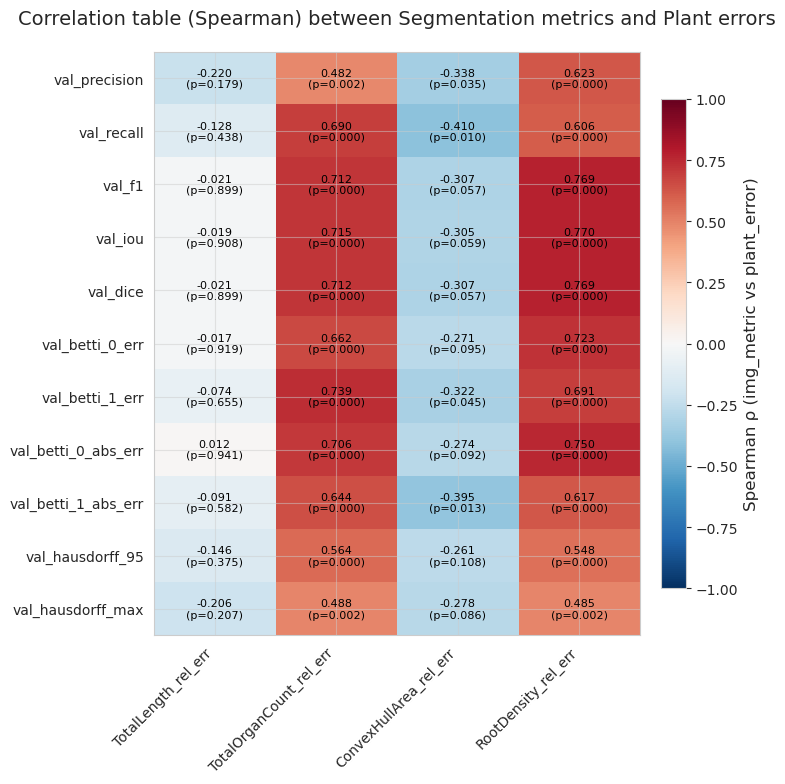

In [68]:
import numpy as np
from scipy.stats import spearmanr

rho_rows, p_rows = [], []
for img_met in img_metrics:
    rho_row, p_row = {}, {}
    for plant_err in plant_rel_err:
        #valid = df_diff_log[[img_met, plant_err]].dropna().copy()
        valid = df_diff_log_epoch_mean[[img_met, plant_err]].dropna().copy()
        if len(valid) < 3:
            rho, p = np.nan, np.nan
        else:
            if img_met in scores_img_metrics:
                valid[img_met] = - valid[img_met]
            rho, p = spearmanr(valid[img_met], valid[plant_err])
        rho_row[plant_err] = float(rho) if np.isfinite(rho) else np.nan
        p_row[plant_err]   = float(p) if np.isfinite(p) else np.nan
    rho_rows.append(pd.Series(rho_row, name=img_met))
    p_rows.append(pd.Series(p_row, name=img_met))

CorrSpearman = pd.DataFrame(rho_rows)
Pvalues      = pd.DataFrame(p_rows)

print("Corrélation (ρ Spearman):")
display(CorrSpearman.round(3))

print("p-values:")
display(Pvalues.applymap(lambda x: round(x, 3) if pd.notna(x) else x))

# --- Heatmap simple (matplotlib) centrée sur 0 ---
plt.figure(figsize=(1.2*len(plant_rel_err)+3, 0.45*len(img_metrics)+3))
im = plt.imshow(CorrSpearman.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Spearman ρ (img_metric vs plant_error)")
plt.yticks(range(len(img_metrics)), img_metrics)
plt.xticks(range(len(plant_rel_err)), plant_rel_err, rotation=45, ha="right")
plt.title("Correlation table (Spearman) between Segmentation metrics and Plant errors", pad=20)

# Annotations: ρ
for i in range(len(img_metrics)):
    for j in range(len(plant_rel_err)):
        rho = CorrSpearman.iat[i, j]
        p = Pvalues.iat[i, j]
        txt = "" if np.isnan(rho) else f"{rho:.3f}\n(p={p:.3f})"
        plt.text(j, i, txt, ha='center', va='center', fontsize=8, color="black")
plt.tight_layout()
plt.savefig("corr_img_to_plant_error_spearman.png", transparent=True, dpi=600)
plt.show()

# Option: export CSV
#CorrSpearman.to_csv("corr_img_to_plant_error_spearman.csv")
#Pvalues.to_csv("corr_img_to_plant_error_spearman_pvalues.csv")